In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator
import thermoift.PLOT_SETTINGS as ps

In [2]:
# Options: "train" | "test" | "val" | "all"
SPLIT = "all"

# Tukey fence multiplier — larger k = fewer outliers flagged
K = 50

In [3]:
NOTEBOOK_DIR = os.path.abspath("")
PRED_CSV     = os.path.join(NOTEBOOK_DIR, "TabPFN_gamma_predictions.csv")
DATASET_CSV  = os.path.join(NOTEBOOK_DIR, "..", "..", "interfacial_results_dataset_A1.csv")
OUTPUT_DIR   = NOTEBOOK_DIR

Z_COLS = [
    "z_carbon dioxide", "z_hydrogen", "z_nitrogen", "z_argon",
    "z_methane", "z_oxygen", "z_water", "z_carbon monoxide",
    "z_nitrogen dioxide", "z_nitrogen oxide", "z_sulfur dioxide",
    "z_hydrogen sulfide", "z_propane", "z_ethane",
]

In [4]:
preds   = pd.read_csv(PRED_CSV)
df_orig = pd.read_csv(DATASET_CSV)

print(f"Predictions : {len(preds)} rows  |  splits: {preds['split'].value_counts().to_dict()}")
print(f"Dataset     : {len(df_orig)} rows")

Predictions : 19171 rows  |  splits: {'train': 13419, 'test': 2876, 'val': 2876}
Dataset     : 19171 rows


In [5]:
subset = preds.copy() if SPLIT == "all" else preds[preds["split"] == SPLIT].copy()

subset["residual"]     = subset["actual"] - subset["predicted"]
subset["abs_residual"] = subset["residual"].abs()

Q1, Q3 = subset["abs_residual"].quantile([0.25, 0.75])
IQR     = Q3 - Q1
fence   = Q3 + K * IQR

outliers    = subset[subset["abs_residual"] >  fence].copy()
non_outlier = subset[subset["abs_residual"] <= fence].copy()

print(f"Split analysed        : {SPLIT}")
print(f"Total points          : {len(subset)}")
print(f"IQR fence (k={K})     : {fence:.6f}  (Q3={Q3:.6f}, IQR={IQR:.6f})")
print(f"Outliers found        : {len(outliers)}")

Split analysed        : all
Total points          : 19171
IQR fence (k=50)     : 0.275822  (Q3=0.007290, IQR=0.005371)
Outliers found        : 10


In [6]:
if not outliers.empty:
    orig_rows = df_orig.iloc[outliers["idx"].values].copy()
    orig_rows.index = outliers.index
    detail = pd.concat(
        [outliers[["idx", "split", "actual", "predicted", "residual", "abs_residual"]], orig_rows],
        axis=1
    )

    z_present = [c for c in Z_COLS if c in df_orig.columns and (orig_rows[c] != 0).any()]
    report_cols = ["idx", "split", "actual", "predicted", "residual", "abs_residual",
                   "temperature", "pressure"] + z_present + ["source_id"]

    display(detail[report_cols].sort_values("abs_residual", ascending=False))
else:
    print("No outliers found at this threshold.")

,idx,split,actual,predicted,residual,abs_residual,temperature,pressure,z_carbon dioxide,z_methane,z_oxygen,z_carbon monoxide,z_hydrogen sulfide,source_id
3067,13023,train,14.247244,12.344060,1.903184,1.903184,225.0,8.265247,0.97,0.000000,0.004938,0.00,0.025062,68
715,1747,train,14.243983,12.375640,1.868343,1.868343,225.0,8.140476,0.97,0.001084,0.004826,0.00,0.024090,9
13692,13024,test,14.208763,12.811695,1.397068,1.397068,225.0,8.458077,0.97,0.000000,0.004938,0.00,0.025062,68
14049,13022,test,14.286283,13.083364,1.202919,1.202919,225.0,8.072416,0.97,0.000000,0.004938,0.00,0.025062,68
8659,1748,train,14.201544,13.036463,1.165081,1.165081,225.0,8.340508,0.97,0.001084,0.004826,0.00,0.024090,9
6453,1746,train,14.287916,13.433798,0.854118,0.854118,225.0,7.940443,0.97,0.001084,0.004826,0.00,0.024090,9
16804,12971,val,21.053213,20.656673,0.396540,0.396540,200.0,2.202396,0.97,0.000000,0.004938,0.00,0.025062,68
13760,14710,test,21.271958,20.956146,0.315812,0.315812,200.0,2.197063,0.95,0.000000,0.020000,0.00,0.030000,77
4368,1691,train,21.010123,20.715525,0.294598,0.294598,200.0,2.211694,0.97,0.001084,0.004826,0.00,0.024090,9
12792,16672,train,21.681737,21.389057,0.292680,0.292680,200.0,2.105456,0.95,0.000000,0.000000,0.01,0.040000,87


In [10]:
if not outliers.empty and "P_bubble" in detail.columns:
    detail["P_over_Pbubble"] = detail["pressure"] / detail["P_bubble"]
    display(
        detail[["idx", "split", "temperature", "pressure", "P_bubble", "P_over_Pbubble", "source_id"]]
        .sort_values("P_over_Pbubble", ascending=False)
    )

,idx,split,temperature,pressure,P_bubble,P_over_Pbubble,source_id
13692,13024,test,225.0,8.458077,8.651008,0.977698,68
3067,13023,train,225.0,8.265247,8.651008,0.955409,68
8659,1748,train,225.0,8.340508,8.740674,0.954218,9
14049,13022,test,225.0,8.072416,8.651008,0.933119,68
715,1747,train,225.0,8.140476,8.740674,0.931333,9
6453,1746,train,225.0,7.940443,8.740674,0.908448,9
16804,12971,val,200.0,2.202396,3.555477,0.619438,68
4368,1691,train,200.0,2.211694,3.616115,0.611622,9
13760,14710,test,200.0,2.197063,7.238929,0.303507,77
12792,16672,train,200.0,2.105456,8.342549,0.252376,87


In [8]:
if not outliers.empty:
    out_csv = os.path.join(OUTPUT_DIR, "parity_outliers.csv")
    detail.to_csv(out_csv, index=False)
    print(f"Outlier table saved → {out_csv}")

Outlier table saved → /home/darshan/A6/PCSAFT_cDFT/ML/TabPFN/SLURM_gamma/parity_outliers.csv


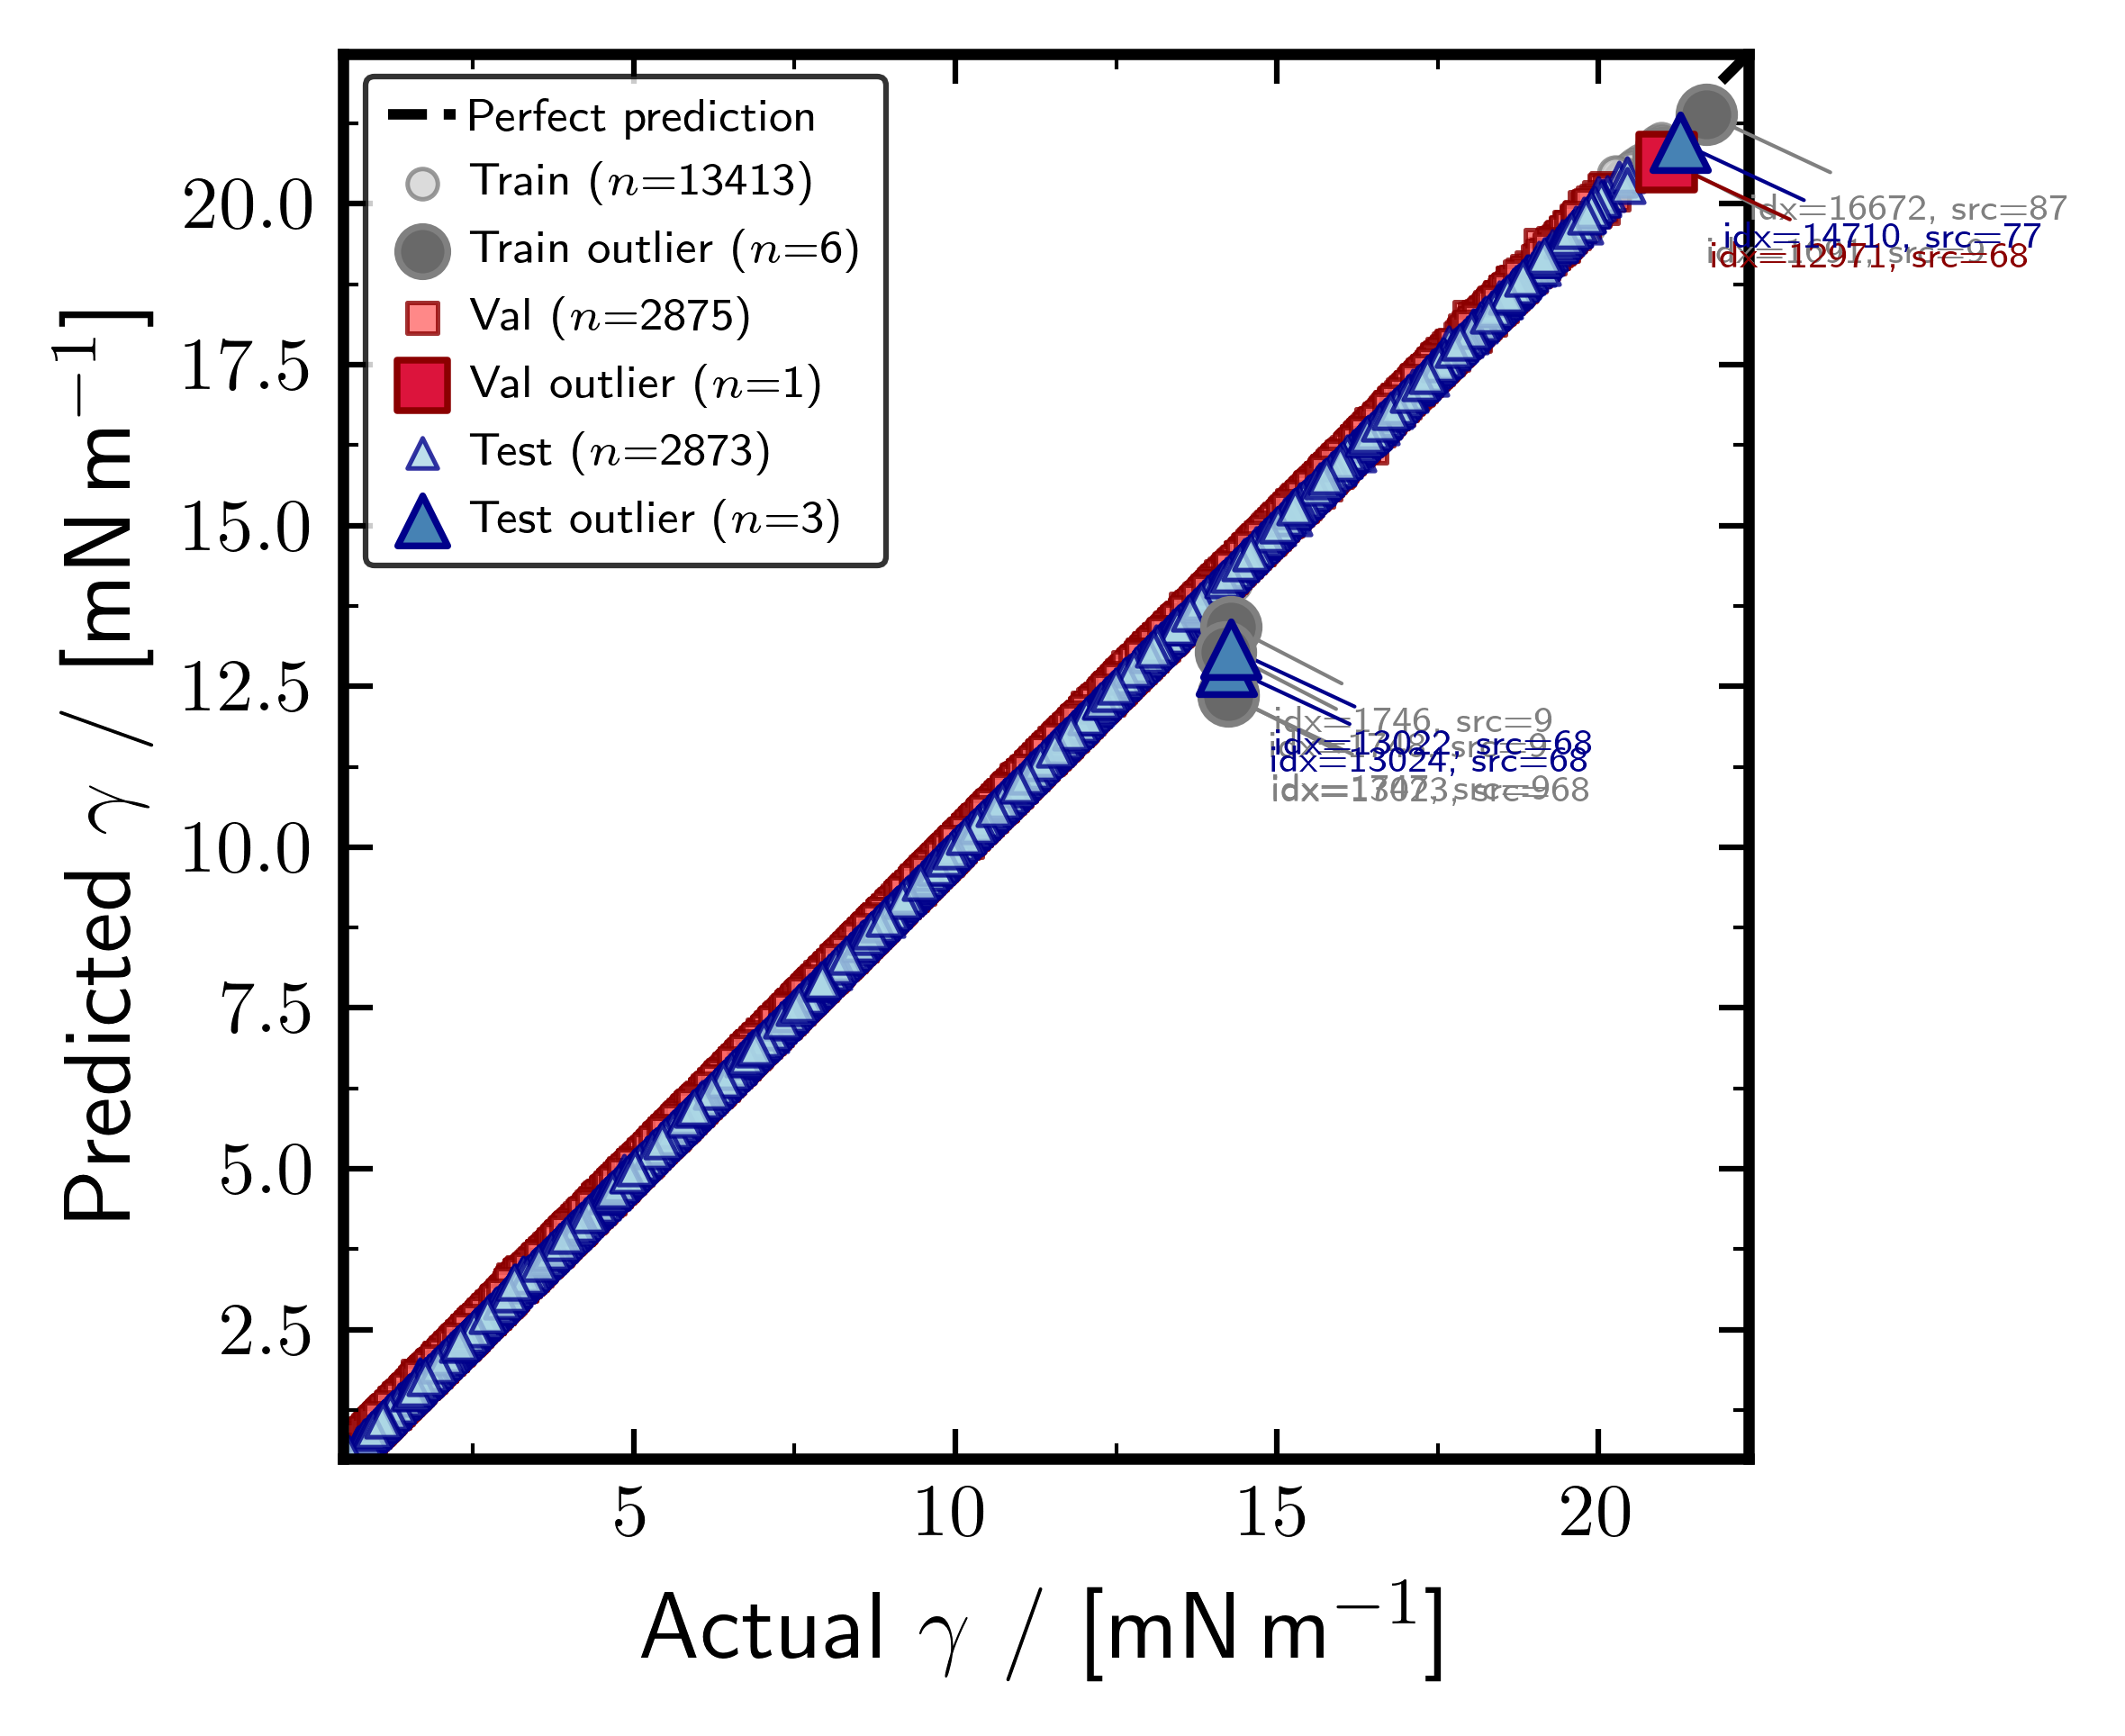

In [11]:
# Split colours matching thermoift SPLIT_COLORS
SPLIT_STYLE = {
    "train": dict(facecolor="lightgray",  edgecolor="gray",     marker="o", label="Train"),
    "val":   dict(facecolor="#FF6B6B",    edgecolor="darkred",  marker="s", label="Val"),
    "test":  dict(facecolor="lightblue",  edgecolor="darkblue", marker="^", label="Test"),
}
OUTLIER_FACE = {
    "train": "dimgray",
    "val":   "crimson",
    "test":  "steelblue",
}

fig, ax = ps.plot_init(w=4, h=4)

lo = subset[["actual", "predicted"]].min().min() * 0.97
hi = subset[["actual", "predicted"]].max().max() * 1.03
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.4, label="Perfect prediction", zorder=0)

splits_present = subset["split"].unique()

for sp in ["train", "val", "test"]:
    if sp not in splits_present:
        continue
    st = SPLIT_STYLE[sp]
    sp_normal   = non_outlier[non_outlier["split"] == sp]
    sp_outliers = outliers[outliers["split"] == sp] if not outliers.empty else pd.DataFrame()

    # Normal points
    if not sp_normal.empty:
        ax.scatter(sp_normal["actual"], sp_normal["predicted"],
                   alpha=0.8, s=20,
                   facecolors=st["facecolor"], edgecolors=st["edgecolor"],
                   linewidths=0.6, marker=st["marker"],
                   label=rf"{st['label']} ($n$={len(sp_normal)})",
                   rasterized=True)

    # Outlier points – darker fill, larger marker
    if not sp_outliers.empty:
        ax.scatter(sp_outliers["actual"], sp_outliers["predicted"],
                   alpha=1.0, s=55, zorder=5,
                   facecolors=OUTLIER_FACE[sp], edgecolors=st["edgecolor"],
                   linewidths=0.9, marker=st["marker"],
                   label=rf"{st['label']} outlier ($n$={len(sp_outliers)})")

        for _, row in sp_outliers.iterrows():
            orig = df_orig.iloc[int(row["idx"])]
            src  = int(orig["source_id"]) if "source_id" in orig else ""
            ax.annotate(rf"idx={int(row['idx'])}, src={src}",
                        xy=(row["actual"], row["predicted"]),
                        xytext=(6, -14), textcoords="offset points",
                        fontsize=5, color=st["edgecolor"],
                        arrowprops=dict(arrowstyle="-", color=st["edgecolor"], lw=0.5))

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")

ax.set_xlabel(r"Actual $\gamma$ / [mN\,m$^{-1}$]",   fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Predicted $\gamma$ / [mN\,m$^{-1}$]", fontsize=ps.label_fontsize * 0.9)
# ax.set_title(rf"Parity plot -- {SPLIT} split(s) $|$ fence: $k={K}$",
#              fontsize=ps.title_fontsize)

ps.style_legend(ax, fontsize=ps.legend_fontsize * 0.75, loc="upper left")

plt.tight_layout()

ps.save_plot(fig, "parity_outliers_annotated", folder=OUTPUT_DIR)
plt.show()